In [2]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
# import src.statsmodels as statsmodels 
import copy
import statsmodels.api as sm
from statsmodels.formula.api import ols


In [3]:
model = "word_task_v10_main_feature_gain_config_latest_ckpt"

analysis_dir = Path(f"/om/scratch/Thu/imgriff/binaural_unit_activations_for_anova/{model}")
anova_results = list(analysis_dir.glob("*.npz"))

h5_fn = analysis_dir / f"{model}_model_activations_3dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
print(h5.keys())
# for key in h5.keys():
    # print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()
valid_ixs = ~np.isnan(target_f0s)

target_f0s = target_f0s[valid_ixs]
target_locs = target_locs[valid_ixs]
target_words = h5["target_word_int"][valid_ixs]
unique_word_int = np.unique(target_words)

<KeysViewHDF5 ['cochleagram_mixture', 'conv_block_0_relu_mixture', 'conv_block_1_relu_mixture', 'conv_block_2_relu_mixture', 'conv_block_3_relu_mixture', 'conv_block_4_relu_mixture', 'conv_block_5_relu_mixture', 'conv_block_6_relu_mixture', 'layer_names', 'relufc_mixture', 'target_f0', 'target_loc', 'target_word_int', 'tested_azims', 'tested_elevs']>


### For spatial tuning analysis, average over examples presented at same location, and compare across locations. 



250
Optimal number of bins: 15


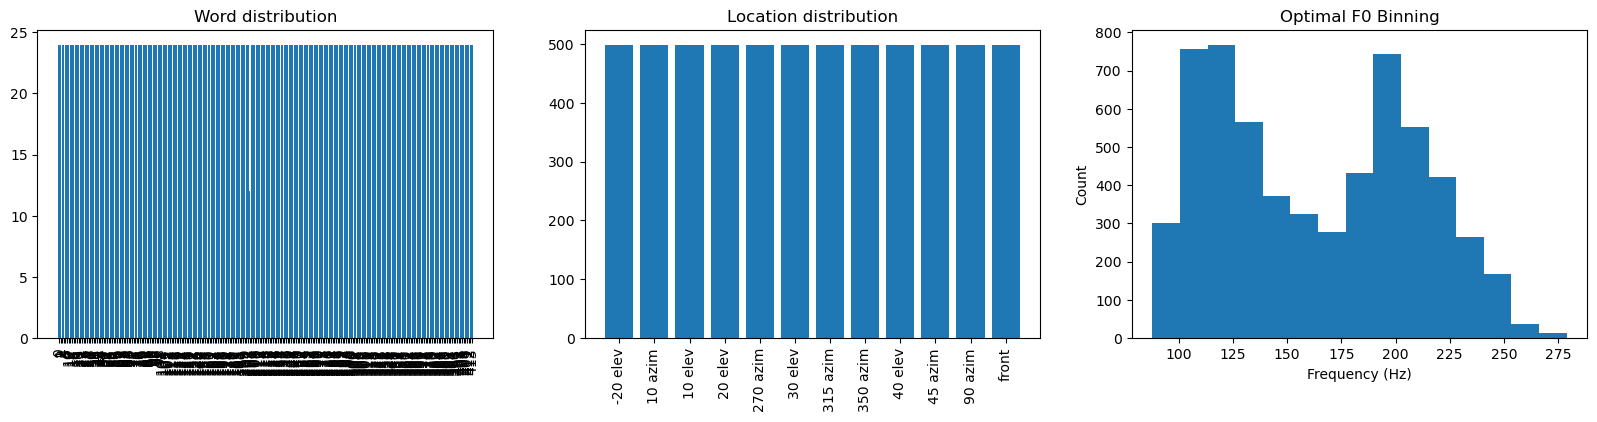

In [8]:
plt.figure(figsize=(20, 4))
plt.subplot(131)
words, count = np.unique(target_words, return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(words))
plt.xticks(np.arange(len(count)), words.astype('int'), rotation=90);
plt.title('Word distribution')

### get binning for location classes 

#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
loc_list = np.zeros(len(target_locs), dtype=object)
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        loc_list[loc_ixs] = 'front'
    elif elev == 0:
        loc_list[loc_ixs] = f"{azim} azim"
    elif azim == 0:
        loc_list[loc_ixs] = f"{elev} elev"

plt.subplot(132)
locs, count = np.unique(loc_list, return_counts=True)
plt.bar(np.arange(len(count)), count)
plt.xticks(np.arange(len(locs)), locs, rotation=90);
plt.title('Location distribution')


### get binning for pitch classes 
def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

plt.subplot(133)
# Example usage with target_f0s data
# target_f0s = np.random.rand(100) * 100  # Replace with your actual data
optimal_bins = 15 #  optimal_bin_count(target_f0s)
print(f"Optimal number of bins: {optimal_bins}")

# Plot the histogram with the optimal number of bins
plt.hist(target_f0s, bins=optimal_bins)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('Optimal F0 Binning')
plt.show()




In [9]:
results_dict = {}

for result in anova_results:
    layer_name = "_".join(result.stem.split("_")[:3])
    if layer_name not in results_dict:
        results_dict[layer_name] = {"prop_var_exp": [], 'ssq_per_unit':[]}
    results = np.load(result)
    results_dict[layer_name]["prop_var_exp"].append(results['prop_var_per_unit'])
    results_dict[layer_name]["ssq_per_unit"].append(results['ssq_per_unit'])

## Concat results across all units
for layer in results_dict.keys():
    results_dict[layer]["prop_var_exp"] = np.concatenate(results_dict[layer]["prop_var_exp"])
    results_dict[layer]["ssq_per_unit"] = np.concatenate(results_dict[layer]["ssq_per_unit"])
    print(layer, results_dict[layer]["prop_var_exp"].shape, results_dict[layer]["ssq_per_unit"].shape)

conv_block_2 (1024, 3) (1024, 3)
conv_block_0 (2496, 3) (2496, 3)
conv_block_1 (2432, 3) (2432, 3)


(0.0, 0.8)

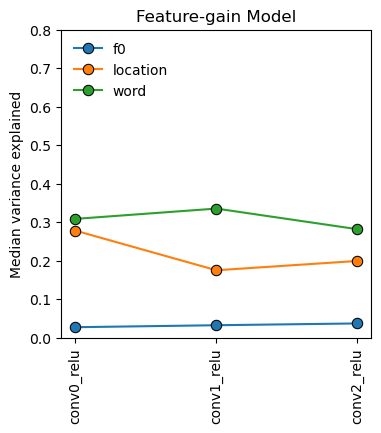

In [19]:
## get info for lineplot 
fig, ax = plt.subplots(1, figsize=(4,4))

var_thresh = 0.1


for ix, feature in enumerate(['f0', 'location', 'word']):
    median_var_exp = np.zeros(len(results_dict))
    for layer, data in results_dict.items():
        # print(layer)
        layer_ix = int(layer.split("_")[-1])
        median_var_exp[layer_ix] = np.nanmedian(data['prop_var_exp'][:,ix])
        
    ax.plot(
        np.arange(len(results_dict)),
        median_var_exp,
        label=feature,
        color=f"C{ix}",
        marker='o',
        markersize=7.5,
        markeredgecolor='k',
        markeredgewidth=0.75,
        )
# plt.xlabel('Convolutional Block')
xtick_labels = [f"conv{i}_relu" for i in range(len(results_dict))]
plt.xticks(np.arange(len(results_dict)), xtick_labels, rotation=90)
plt.ylabel(f'Median variance explained')
plt.title(f"Feature-gain Model")
plt.legend(frameon=False, loc='upper left')
plt.ylim(0, 0.8)



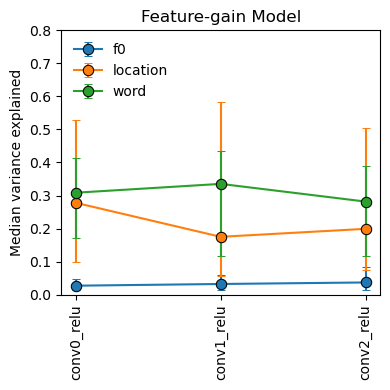

In [18]:
fig, ax = plt.subplots(1, figsize=(4, 4))

var_thresh = 0.1

for ix, feature in enumerate(['f0', 'location', 'word']):
    median_var_exp = np.zeros(len(results_dict))
    q25_var_exp = np.zeros(len(results_dict))
    q75_var_exp = np.zeros(len(results_dict))
    
    for layer, data in results_dict.items():
        layer_ix = int(layer.split("_")[-1])
        median_var_exp[layer_ix] = np.nanmedian(data['prop_var_exp'][:, ix])
        q25_var_exp[layer_ix] = np.nanpercentile(data['prop_var_exp'][:, ix], 25)
        q75_var_exp[layer_ix] = np.nanpercentile(data['prop_var_exp'][:, ix], 75)
    
    x_values = np.arange(len(results_dict))
    
    # Compute asymmetric error bars
    lower_err = median_var_exp - q25_var_exp
    upper_err = q75_var_exp - median_var_exp
    yerr = np.vstack([lower_err, upper_err])
    
    # Plot with error bars
    ax.errorbar(
        x_values,
        median_var_exp,
        yerr=yerr,
        label=feature,
        color=f"C{ix}",
        marker='o',
        markersize=7.5,
        markeredgecolor='k',
        markeredgewidth=0.75,
        linestyle='-',
        capsize=3,
        linewidth=1.5
    )

xtick_labels = [f"conv{i}_relu" for i in range(len(results_dict))]
plt.xticks(np.arange(len(results_dict)), xtick_labels, rotation=90)
plt.ylabel('Median variance explained')
plt.title('Feature-gain Model')
plt.legend(frameon=False, loc='upper left')
plt.ylim(0, 0.8)
plt.tight_layout()
